# 2 · Modelos de reconstrucción: AE → DAE → híbrido → VAE

**Autoencoders**: se entrenan a reconstruir las campañas normales; lo que
reconstruyen mal = anómalo. Recorremos los intentos en orden, siempre vs el baseline.

> *Fase de exploración*, sobre el panel original (la limpieza de datos es el NB 4). Importa
> la **comparación relativa** entre enfoques; los números absolutos suben después.

In [1]:
import os, explib
os.chdir(explib.ROOT)          # rutas relativas (data/, configs/, runs/) funcionan
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
plt.rcParams['figure.dpi'] = 110

## 2.1 — Autoencoder (AE)
Arquitectura: encoder comprime las 54 features a un latente chico, decoder reconstruye.
Score = error de reconstrucción (MSE). Veamos un config y su estructura:

In [2]:
explib.describe_architecture("configs/ae/ae_v11_cosine_deep.yaml")

Modelo: AE
  Encoder:  54 → 128 → 64 → 16 (latente)
  Decoder:  16 → 64 → 128 → 54

  Optimización: lr=0.001 epochs=300 patience=40 batch=64 n_seeds=10


Entrenamos **24 variantes** (arquitectura, latente, dropout, schedules). Los 5 mejores:

In [3]:
explib.show(explib.top_runs("ae", "soja", n=5, era="dirty"))

,name,pr_auc,pr_std,roc,rec_k,n_seeds
0,ae_v23_longer,0.3773,0.0282,0.6646,0.1823,10
1,ae_v12_plateau_deep,0.3748,0.0330,0.6583,NaN,10
2,ae_v11_cosine_deep,0.3741,0.0291,0.6596,NaN,10
3,ae_v21_batch_small,0.3692,0.0149,0.6552,0.1910,10
4,ae_v18_lr_low,0.3683,0.0258,0.6567,0.1826,10


El rango entre las 24 fue de **~0.034**: tunear hiperparámetros casi no movió la
aguja → el cuello de botella no era ése. Curva de loss y métricas del mejor AE:

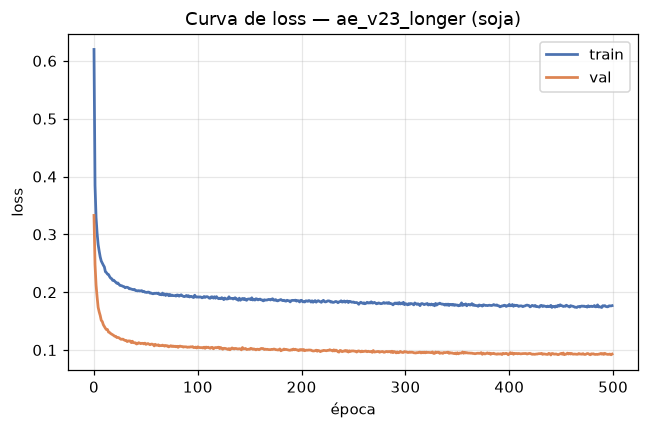

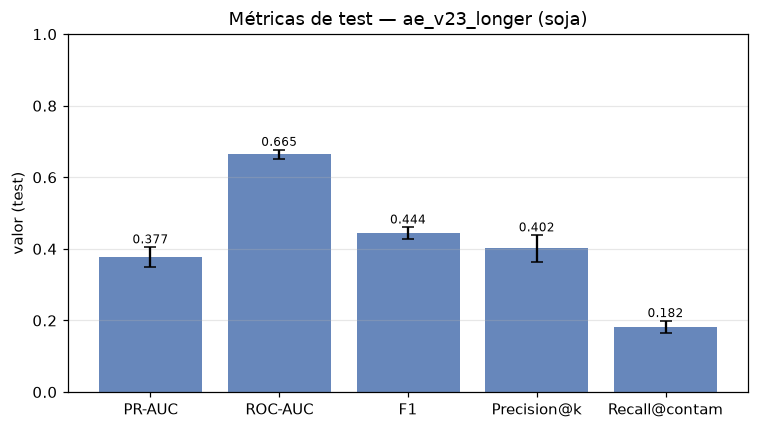

In [4]:
best_ae = explib.top_runs("ae","soja",1,era="dirty")["name"].iloc[0]
explib.plot_loss(best_ae, "soja"); plt.show()
explib.plot_all_metrics(best_ae, "soja"); plt.show()

## 2.2 — Denoising AE (DAE)
Se entrena reconstruyendo *limpio* desde input *corrupto* → más robusto al ruido. Ayuda
algo, pero sigue en el rango del AE.

In [5]:
explib.show(explib.compare_table([("dae_v1_base","DAE base"), ("dae_v2_sweep_best","DAE sweep")], "soja"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,DAE base,0.383±0.072,0.649±0.060,0.367±0.115,0.408±0.057,0.155±0.050
1,DAE sweep,0.360±0.019,0.640±0.022,0.202±0.046,0.414±0.020,0.140±0.020


## 2.3 — Híbrido: AE-latente + Isolation Forest
Correr IForest sobre el **latente** del AE. En la literatura suele ganar; acá **falló** — el
bottleneck del AE destruye la estructura que el IForest necesita.

In [6]:
explib.show(explib.compare_table([("ae_iforest_v1","híbrido lat8"), ("ae_iforest_v2_latent16","híbrido lat16")], "soja"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,híbrido lat8,0.271±0.071,0.506±0.077,0.339±0.042,0.264±0.092,0.129±0.063
1,híbrido lat16,0.307±0.062,0.548±0.064,0.354±0.047,0.310±0.063,0.162±0.044


## 2.4 — VAE: el salto del *score probabilístico*
El VAE usa `recon_prob` (An & Cho 2015): pondera el error de cada feature por la **varianza
que el decoder le asigna**. Ese cambio de *score* (no de arquitectura) es lo que mueve la
aguja.

In [7]:
explib.describe_architecture("configs/vae/vae_v4_reconprob_lat16.yaml")

Modelo: VAE
  Encoder:  54 → 64 → 32 → 16 (latente)
  Decoder:  16 → 32 → 64 → 54
  Score:    recon_prob  (recon_prob = -E[log p(x|z)], pondera por varianza per-feature)
  beta(KL): 1.0

  Optimización: lr=0.001 epochs=300 patience=30 batch=64 n_seeds=10


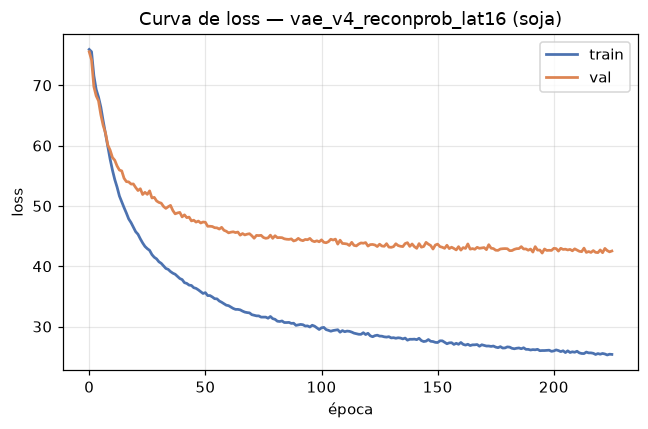

In [8]:
explib.plot_loss("vae_v4_reconprob_lat16", "soja"); plt.show()

### Comparación de toda la fase (test, media±std) — misma era (panel original)

In [9]:
recon = [("iforest_v1_base","IForest (baseline)"), (best_ae,"AE (mejor)"),
         ("ae_iforest_v2_latent16","Híbrido AE+IForest"), ("vae_v4_reconprob_lat16","VAE recon_prob")]
explib.show(explib.compare_table(recon, "soja", era="dirty"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,IForest (baseline),—,—,—,—,—
1,AE (mejor),0.377±0.028,0.665±0.013,0.444±0.017,0.402±0.037,0.182±0.017
2,Híbrido AE+IForest,0.307±0.062,0.548±0.064,0.354±0.047,0.310±0.063,0.162±0.044
3,VAE recon_prob,0.435±0.031,0.667±0.029,0.414±0.023,0.434±0.045,0.237±0.022


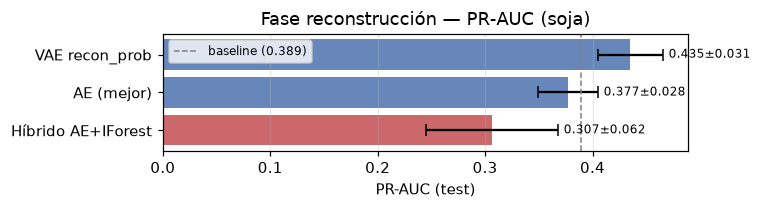

In [10]:
explib.plot_compare(recon, "soja", era="dirty", baseline=0.389, title="Fase reconstrucción — PR-AUC (soja)"); plt.show()

### Matriz de confusión por tipo de modelo (re-umbralizado sobre test)
Más allá del ranking PR-AUC, así se ve el **punto de operación** de cada tipo de modelo. Como
en el NB 1, re-umbralizamos sobre los scores del propio test en dos puntos: **top-10%**
(presupuesto) y **top-tasa real** (~27%). Filas del grid = punto de operación; columnas =
tipo de modelo. Se ve qué enfoque rankea mejor las anomalías a igual presupuesto de alertas.

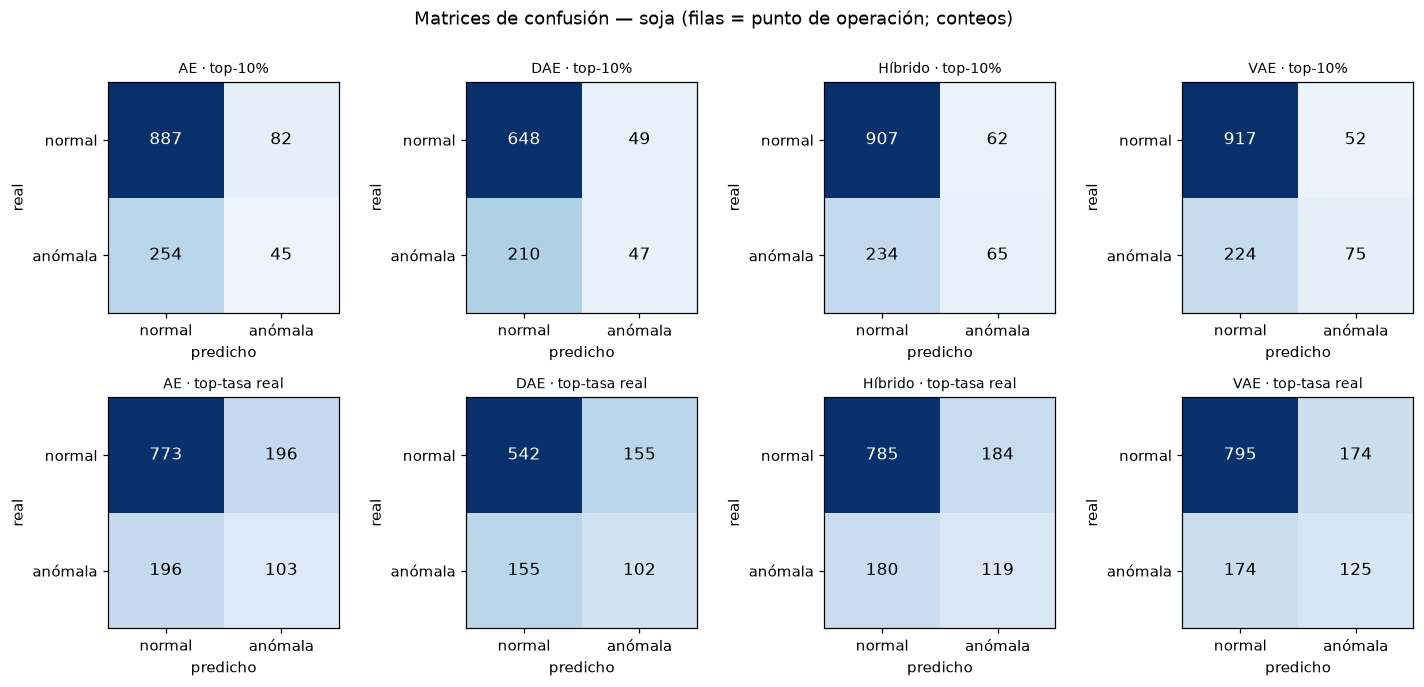

In [11]:
recon_cm = [(best_ae, "AE"), ("dae_v1_base", "DAE"),
            ("ae_iforest_v2_latent16", "Híbrido"), ("vae_v4_reconprob_lat16", "VAE")]
explib.plot_confusion_grid(recon_cm, "soja", era="dirty"); plt.show()

### Distribución del score por tipo de modelo (el histograma de la app)
Score de las campañas **normales** (azul) vs **anómalas** (naranja) en test. Cuanto más
**separadas** las dos distribuciones, mejor rankea el modelo. Se ve por qué el VAE
`recon_prob` gana: corre la cola de las anómalas más a la derecha que el AE/híbrido.

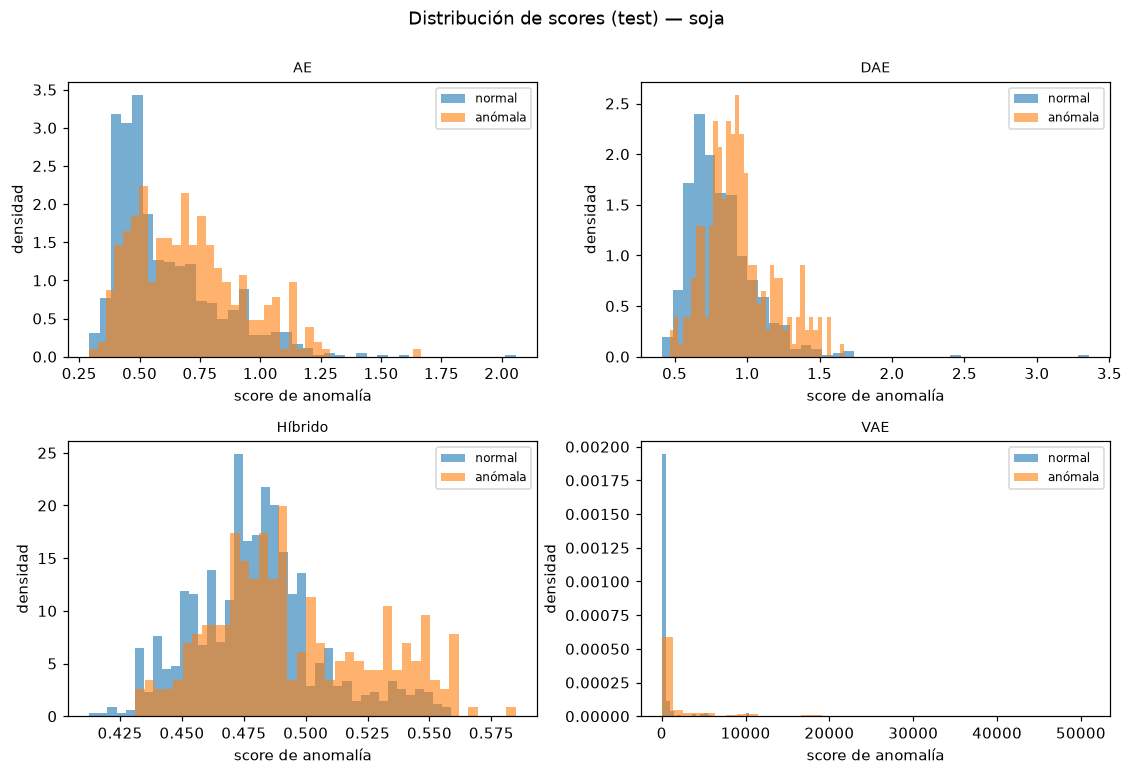

In [12]:
explib.plot_score_hist_grid(recon_cm, "soja", era="dirty"); plt.show()

**Conclusión:** el **VAE `recon_prob`** es el mejor modelo de reconstrucción y el
único que le pelea al baseline. Pero tiene **alta varianza** (±0.03) — lo atacamos en el NB 3.